Best score: 0.831505376344086
Best params: {'pca__n_components': 10, 'svc__C': 1, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
Test accuracy: 0.6753


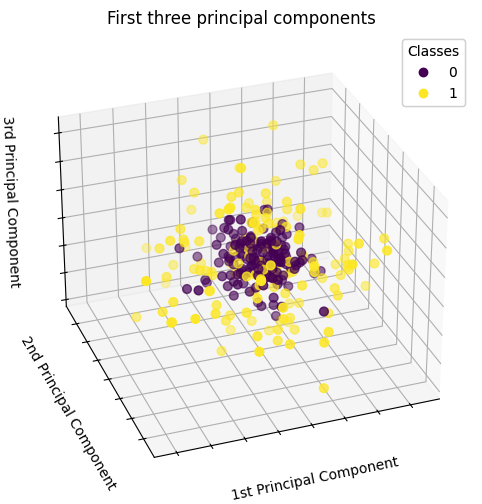

Soggetto 001 - Test accuracy LDA: 0.4870
Best score: 0.6979569892473119
Best params: {'pca__n_components': 20, 'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Test accuracy: 0.7727


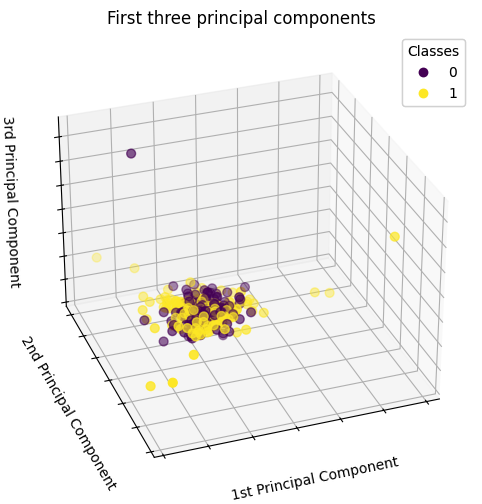

Soggetto 002 - Test accuracy LDA: 0.4675


KeyboardInterrupt: 

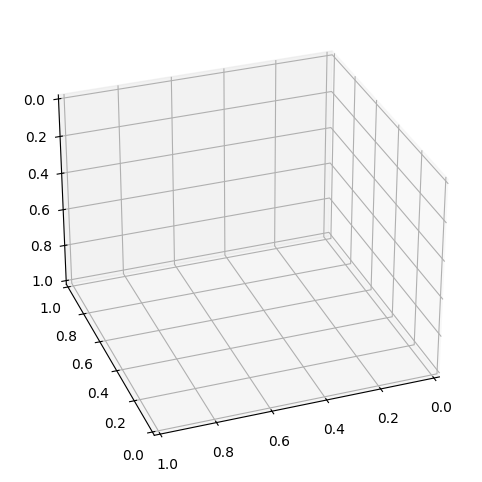

In [ ]:
# 12/5: creato per plottare i risultati del PCA e vedere la separazione tra le classi
# Risultati: CSP sembra fornire prestazioni generalmente migliori. Per completezza può essere opportuno eseguire un'analisti più approfondita
# che faccia uso di ICA. 
# TODO: inoltre, attualmente, la gridSearch è computazionalmente molto costosa e non permette di effettuare una valutazione su un numero
# sufficiente di pazienti (finora sono stati effettuati test solo sui primi 3 pazienti)
import mne
from mne_bids import BIDSPath, read_raw_bids
import numpy as np
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from pathlib import Path
from util.preprocessing import create_sliding_windows
from util.preprocessing import create_window_labels
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectPercentile, f_classif


mne.set_log_level('WARNING')

root = "../data"
root = (Path(root).resolve())
runs = ["6", "10", "14"]   # Le run che vengono prese in considerazione
train_runs = ["6", "10"]
test_run = "14" 
first_person = 1
people = 10
all_accuracy = np.zeros(people)  # Per memorizzare l'accuratezza di ogni soggetto

# Eseguiamo la scansione di tutti i soggetti 
for i in range(first_person, first_person + people):
    subject = f"{i:03d}"
    X_train = []
    y_train = []

    X_test = []
    y_test = []

    # Per ogni soggetto eseguiamo la scansione sulle run di nostro interesse
    for run in runs:
        bids_path = BIDSPath(   # Specifichiamo il percorso del dataset e BIDS eseguirà correttamente la scansione 
            subject=subject,
            task="motion",
            run=run,
            datatype="eeg",
            root=root,
        )
        
        try:
            # Fase 1: lettura dei dati
            raw = read_raw_bids(bids_path, verbose=False)  
            events, event_id = mne.events_from_annotations(raw, verbose=False) 
            raw.load_data(verbose=False) # Carico i dati in memoria per poter filtrare ecc.
            raw.filter(l_freq=8, h_freq=30, verbose=False)  # Filtro passa banda 1-30 Hz
            raw.set_eeg_reference('average', projection=False, verbose=False)  # Riferimento medio
            event_map = {
                event_id['TASK4T0']: 1,
                event_id['TASK4T1']: 2,
                event_id['TASK4T2']: 3
            }
            sfreq = raw.info['sfreq']  # frequenza di campionamento

            # Fase 2: pre-processing
            window_size = 1.5  # Lunghezza finestra in secondi
            step_size = 0.3  # Lunghezza passo in secondi

            windows, window_samples, step_samples, total_samples = create_sliding_windows(
                raw,
                window_size,
                step_size
            )        

            C_channels = ["C1", "C2", "C3", "C4", "C5", "C6", "Cz"]
            CP_channels = [ch for ch in raw.ch_names if ch.startswith("Cp")]
            FC_channels = [ch for ch in raw.ch_names if ch.startswith("Fc")]
            T_channels =  [ch for ch in raw.ch_names if ch.startswith("T")]
            F_channels =  ["F1", "F2", "F3", "F4", "F5", "F6"]
            P_channels =  ["P1", "P2", "P3", "P4", "P5", "P6"]
            channels_of_interest = C_channels  + FC_channels + CP_channels 

            picks = mne.pick_channels(raw.ch_names, channels_of_interest)
            windows = windows[:, picks, :]

            y = create_window_labels(
                events,
                event_map,
                total_samples,
                window_samples,
                step_samples,
                threshold= 0.8
            )
            
            # Divido la classificazione in due step: prima distinguo tra stato di riposo e di attivazione.
            # In caso di attivazione, distinguo tra sinistra e destra. Per ora faccio solo la prima parte.
            y_rest_active = np.where(y == 1, 0, 1)  
             
            # Variabile per addestrare il modello sul sinistra/destra (da commentare se non si vuole usare)
            mask_active = y != 1
            y_active = y[mask_active]
            y_lr = np.where(y_active == 2, 0, 1)

            # Assegno a y_binary le etichette desiderate (se voglio rest/active commento la seconda riga)
            y_binary = y_lr
            windows = windows[mask_active]

            windows = windows.reshape(windows.shape[0], -1)

            if run in train_runs:
                X_train.append(windows)
                y_train.append(y_binary)
            else:
                X_test.append(windows)
                y_test.append(y_binary)

            # print(f"Soggetto {subject} run {run} - Campioni: {X_csp.shape[0]}, Feature per campione: {X_csp.shape[1]}, Etichette: {y.shape[0]}")

        except Exception as e:
            print(f"Errore {subject}: {e}")



    X_train = np.concatenate(X_train, axis=0)
    y_train = np.concatenate(y_train)

    X_test = np.concatenate(X_test, axis=0)
    y_test = np.concatenate(y_test)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    fig = plt.figure(1, figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA()),
        ("svc", SVC())
    ])

    param_grid = [
        {
            "pca__n_components": [5, 10, 20, 30, 0.90, 0.95],
            "svc__kernel": ["linear"],
            "svc__C": [0.1, 1, 10, 100]
        },
        {
            "pca__n_components": [5, 10, 20, 30, 0.90, 0.95],
            "svc__kernel": ["rbf"],
            "svc__C": [0.1, 1, 10, 100],
            "svc__gamma": ["scale", 0.1, 0.01]
        }
    ]

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=5,
        scoring="balanced_accuracy",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    print("Best score:", grid.best_score_)
    print("Best params:", grid.best_params_)

    test_accuracy = grid.score(X_test, y_test)
    print(f"Test accuracy: {test_accuracy:.4f}")

    # Ricavo i dati ridotti usando il miglior estimator
    best_pipe = grid.best_estimator_
    X_reduced_train = best_pipe.named_steps["pca"].transform(
        best_pipe.named_steps["scaler"].transform(X_train)
    )
    X_reduced_test = best_pipe.named_steps["pca"].transform(
        best_pipe.named_steps["scaler"].transform(X_test)
    )
    scatter = ax.scatter(
        X_reduced_train[:, 0],
        X_reduced_train[:, 1],
        X_reduced_train[:, 2],
        c=y_train,
        s=40,
    )
    ax.set(
        title="First three principal components",
        xlabel="1st Principal Component",
        ylabel="2nd Principal Component",
        zlabel="3rd Principal Component",
    )
    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.zaxis.set_ticklabels([])

    # Add a legend
    legend1 = ax.legend(
        scatter.legend_elements()[0],
        np.unique(y_train).tolist(),
        loc="upper right",
        title="Classes",
    )
    ax.add_artist(legend1)

    plt.show()

    lda = LinearDiscriminantAnalysis()
    lda.fit(X_reduced_train, y_train)
    test_accuracy_lda = lda.score(X_reduced_test, y_test)
    print(f"Soggetto {subject} - Test accuracy LDA: {test_accuracy_lda:.4f}")


